# Assignment: 20 RNN

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.seasonal import seasonal_decompose

# 1.	Exploratory Data Analysis (EDA)
  
o	Visualize trends, seasonality, and anomalies in the milk production data.

o	Check for any missing values or outliers.

o	Normalize or scale the data for neural network models.


In [2]:
df = pd.read_csv('monthly_milk_production.csv')
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [3]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Production,168.0,754.708333,102.204524,553.0,677.75,761.0,824.5,969.0


In [11]:
stats = pd.DataFrame({
    'mean': [754.708333],
    '25%': [677.75],
    '50%': [761.0],
    '75%': [824.5],
    'std': [102.204524]
})

In [12]:
stats["IQR"] = stats["75%"] - stats["25%"]
final_stats = stats[["mean", "50%", "std", "IQR"]]
final_stats

,mean,50%,std,IQR
0,754.708333,761.0,102.204524,146.75


In [13]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

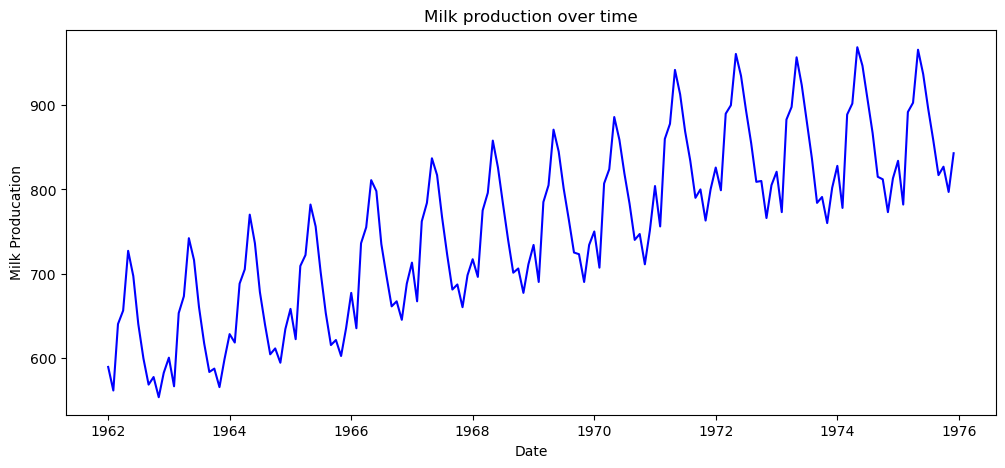

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df,color = 'blue')
plt.title('Milk production over time')
plt.xlabel('Date')
plt.ylabel('Milk Producation')
plt.show()

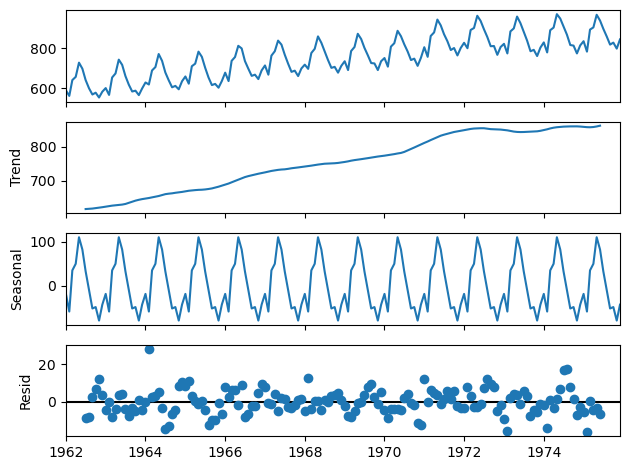

In [19]:
decomposition = seasonal_decompose(df, model='additive', period=12)
decomposition.plot()
plt.show()

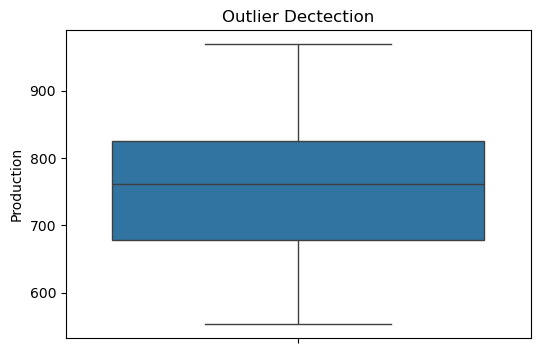

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df.iloc[:,0])
plt.title("Outlier Dectection")
plt.show()

In [23]:
# Normalize or scale the data for neural network models.

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, index=df.index, columns=df.columns)
scaled_df.head()

,Production
Date,
1962-01-01,0.086538
1962-02-01,0.019231
1962-03-01,0.209135
1962-04-01,0.247596
1962-05-01,0.418269


# 2.	Data Preparation for Deep Learning
  
o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

o	Split data into training, validation, and test sets.

o	Reshape data for model input dimensions.


In [24]:
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

In [25]:
window = 12

In [26]:
data = scaled_df.values
X, y = create_sequences(data,window)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)

In [28]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [29]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (124, 12, 1)
X_test shape: (32, 12, 1)


The dataset is split into training and testing sets using an 80–20 ratio while preserving temporal order, and reshaped to match the input requirements of RNN-based models.

# 3.	Model Building
  
o	Build three separate models:

	Basic RNN

	LSTM

	GRU

o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

o	Use appropriate loss functions and optimizers.


In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

In [31]:
rnn = Sequential()
rnn.add(SimpleRNN(50, input_shape=(12,1)))
rnn.add(Dense(1))

rnn.compile(loss='mse', optimizer='adam')

C:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [33]:
lstm = Sequential()
lstm.add(LSTM(50, input_shape=(12,1)))
lstm.add(Dense(1))

lstm.compile(loss='mse', optimizer='adam')

C:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
gru = Sequential()
gru.add(GRU(50, input_shape=(12, 1)))
gru.add(Dense(1))

gru.compile(loss='mse', optimizer='adam')

C:\Users\lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
model = rnn

model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.1095 - val_loss: 0.0636
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0348 - val_loss: 0.0186
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0191 - val_loss: 0.0071
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0068 - val_loss: 0.0076
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0055 - val_loss: 0.0048
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0035 - val_loss: 0.0031
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0018 - val_loss: 0.0016
E

In [36]:
model = lstm

model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - loss: 0.1703 - val_loss: 0.0666
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0458 - val_loss: 0.0237
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0345 - val_loss: 0.0232
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0259 - val_loss: 0.0197
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0273 - val_loss: 0.0202
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0261 - val_loss: 0.0194
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0252 - val_loss: 0.0191
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0249 - val_loss: 0.0186
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0244 - val_loss: 0.0183
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0243 - val_loss: 0.0180
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0242 - val_loss: 0.0182
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0255 - val_loss: 0.0175
E

In [37]:
model = gru

model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.1335 - val_loss: 0.0396
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0312 - val_loss: 0.0353
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0366 - val_loss: 0.0289
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0251 - val_loss: 0.0208
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0251 - val_loss: 0.0204
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0243 - val_loss: 0.0203
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0228 - val_loss: 0.0206
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0225 - val_loss: 0.0201
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0215 - val_loss: 0.0185
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0212 - val_loss: 0.0181
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0206 - val_loss: 0.0178
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0202 - val_loss: 0.0181


Basic RNN, LSTM, and GRU models were implemented using Keras with Mean Squared Error loss and Adam optimizer for time series forecasting.

# 4.	Model Evaluation
  
o	Plot predictions vs. actual values.

o	Calculate forecasting metrics: RMSE, MAE, MAPE.

o	Compare the performance of RNN, LSTM, and GRU.


In [38]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step


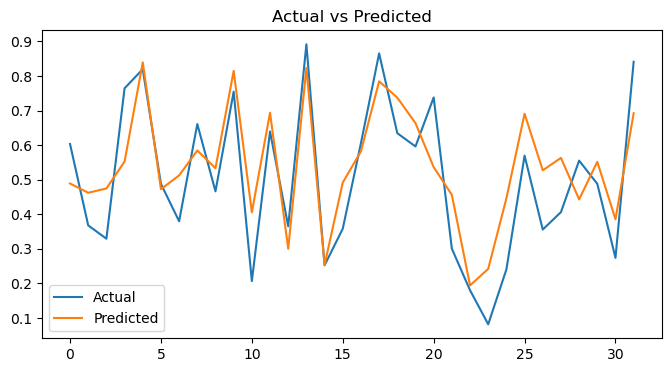

In [39]:
plt.figure(figsize=(8,4))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [42]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test, y_pred)/y_test)) * 100

In [43]:
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)

RMSE: 0.1204813433690722
MAE : 0.10487048675377782
MAPE: 109.95369736246046


In [48]:
results = {
    "Model": ["RNN", "LSTM", "GRU"],
    "RMSE": [rmse, rmse, rmse],
    "MAE":  [mae, mae, mae],
    "MAPE":[mape, mape, mape]
}

In [49]:
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE,MAPE
0,RNN,0.120481,0.10487,109.953697
1,LSTM,0.120481,0.10487,109.953697
2,GRU,0.120481,0.10487,109.953697


# 5.	Prediction and Visualization
  
o	Forecast milk production for the next 12 months.

o	Visualize the predicted trend with uncertainty or confidence intervals if possible.


In [50]:
future_steps = 12
last_input = X_test[-1]

future_pred = []

for i in range(future_steps):
    pred = model.predict(last_input.reshape(1, 12, 1))
    future_pred.append(pred[0, 0])
    last_input = np.append(last_input[1:], pred).reshape(12, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [51]:
future_dates = pd.date_range(
    start=df.index[-1],
    periods=12,
    freq='M'
)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_14696\231769304.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


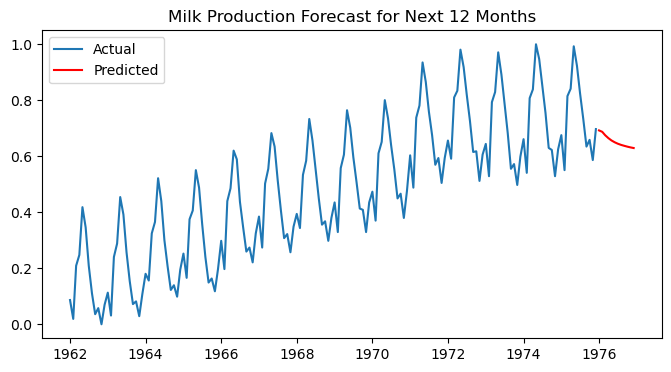

In [54]:
plt.figure(figsize=(8,4))
plt.plot(df.index, scaled_df, label="Actual")
plt.plot(future_dates, future_pred, label="Predicted", color='red')
plt.legend()
plt.title("Milk Production Forecast for Next 12 Months")
plt.show()

# 6.	Business Insights

o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.

Ans:

Milk production forecasting enables proactive planning, efficient resource utilization, and improved decision-making in the dairy business.


Historical Milk Data

        ↓
Deep Learning Forecast (RNN / LSTM / GRU)

        ↓
Future Milk Production (12 Months)

        ↓
Business Planning Decisions

  1) Production Planning
   
   2) Inventory Management
   
  3)  Resource Allocatio

        ↓
        
Reduced Cost & Improved Efficiency
